<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/fnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
# --- Load Data ---
df = pd.read_csv('allDataMean.csv')

In [ ]:
# --- Extract Target Column ---
target_column = 'allDataMean6'
data = df[[target_column]].values

In [ ]:
# --- Normalize ---
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:

# --- Create Sequences ---
def create_sequences(data_seq, seq_length):
    X, y = [], []
    for i in range(len(data_seq) - seq_length):
        X.append(data_seq[i:i+seq_length])
        y.append(data_seq[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

In [ ]:

# --- Train-Test Split ---
split = int(len(X) * 0.8)
x_train = X[:split].reshape((-1, seq_length))
x_test = X[split:].reshape((-1, seq_length))
y_train, y_test = y[:split], y[split:]

In [ ]:
# --- FNN Model ---
model = Sequential([
    Dense(128, activation='relu', input_shape=(seq_length,)),
    Dense(64, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# --- Train ---
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1)

Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.1843e-04 - val_loss: 4.7483e-08
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8.8985e-07 - val_loss: 7.0132e-07
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 2.1543e-06 - val_loss: 2.9952e-07
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.0254e-07 - val_loss: 4.7037e-06
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3.3839e-07 - val_loss: 1.2387e-05
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 6.7265e-07 - val_loss: 3.8544e-08
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.3480e-07 - val_loss: 3.3311e-08
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 2.3306e-07 - val_loss: 3.4719e-06
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3.5119e-07 - val_loss: 4.0697e-07
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 4.6160e-07 - val_loss: 6.4456e-08
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━━

In [ ]:
# --- Predict ---
y_pred = model.predict(x_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
# --- Metrics ---
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f"FNN MAE: {mae:.4f}")
print(f"FNN MSE: {mse:.4f}")
print(f"FNN R² : {r2:.4f}")

FNN MAE: 2.1795
FNN MSE: 62.6231
FNN R² : 0.9426


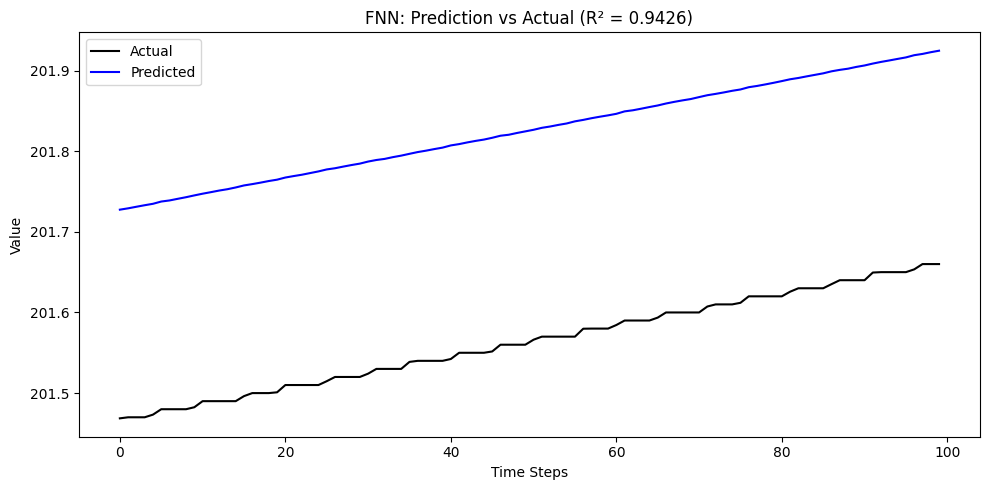

In [ ]:
# --- Line Plot of Prediction ---
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[:100], label='Actual', color='black')
plt.plot(y_pred_inv[:100], label='Predicted', color='blue')
plt.title(f"FNN: Prediction vs Actual (R² = {r2:.4f})")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

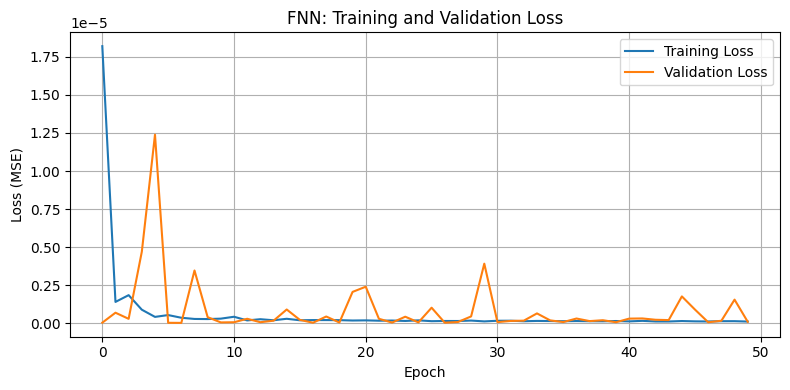

In [ ]:
# --- Training Loss Plot ---
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("FNN: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()